In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("lulc_training_dataset_2.0.csv")
df.head()

,system:index,Q1_B11,Q1_B12,Q1_B2,Q1_B3,Q1_B4,Q1_B5,Q1_B6,Q1_B7,Q1_B8,...,Q4_B2,Q4_B3,Q4_B4,Q4_B5,Q4_B6,Q4_B7,Q4_B8,Q4_B8A,label,.geo
0,0,0.21090,0.16760,0.02660,0.0434,0.0474,0.10740,0.1907,0.22590,0.2392,...,0.03000,0.0412,0.04840,0.09920,0.1577,0.18820,0.2134,0.2141,10,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
1,1,0.17810,0.12405,0.02615,0.0462,0.0399,0.09685,0.2119,0.25570,0.2606,...,0.02240,0.0482,0.03110,0.09820,0.2357,0.28560,0.3166,0.3112,10,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
2,2,0.25470,0.17350,0.04565,0.0653,0.0809,0.11660,0.1649,0.18910,0.1857,...,0.04985,0.0752,0.08985,0.13235,0.1995,0.22575,0.2462,0.2536,10,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
3,3,0.11415,0.06155,0.01465,0.0335,0.0251,0.07450,0.1869,0.23405,0.2648,...,0.01970,0.0378,0.03420,0.08490,0.1900,0.22880,0.2742,0.2485,10,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
4,4,0.15410,0.07840,0.01380,0.0360,0.0291,0.09000,0.2214,0.28070,0.2698,...,0.01940,0.0402,0.03120,0.09440,0.2303,0.28760,0.2724,0.3182,10,"{""geodesic"":false,""type"":""Point"",""coordinates""..."


In [6]:
print(f"shape:{df.shape}")
df.info()
print("isnull:",df.isnull().sum())
print("isduplicate:",df.duplicated().sum())

shape:(90000, 43)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 43 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   system:index  90000 non-null  int64  
 1   Q1_B11        90000 non-null  float64
 2   Q1_B12        90000 non-null  float64
 3   Q1_B2         90000 non-null  float64
 4   Q1_B3         90000 non-null  float64
 5   Q1_B4         90000 non-null  float64
 6   Q1_B5         90000 non-null  float64
 7   Q1_B6         90000 non-null  float64
 8   Q1_B7         90000 non-null  float64
 9   Q1_B8         90000 non-null  float64
 10  Q1_B8A        90000 non-null  float64
 11  Q2_B11        90000 non-null  float64
 12  Q2_B12        90000 non-null  float64
 13  Q2_B2         90000 non-null  float64
 14  Q2_B3         90000 non-null  float64
 15  Q2_B4         90000 non-null  float64
 16  Q2_B5         90000 non-null  float64
 17  Q2_B6         90000 non-null  float64
 18  Q2_B7   

In [7]:
df.describe()

,system:index,Q1_B11,Q1_B12,Q1_B2,Q1_B3,Q1_B4,Q1_B5,Q1_B6,Q1_B7,Q1_B8,...,Q4_B12,Q4_B2,Q4_B3,Q4_B4,Q4_B5,Q4_B6,Q4_B7,Q4_B8,Q4_B8A,label
count,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,...,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000
mean,44999.500000,0.228922,0.174842,0.072493,0.097089,0.117110,0.144432,0.178847,0.195889,0.205050,...,0.163418,0.074651,0.099012,0.116969,0.147503,0.190372,0.209518,0.224286,0.227494,52.777778
std,25980.906451,0.136849,0.118599,0.064163,0.076607,0.094706,0.095533,0.092481,0.095935,0.100124,...,0.112925,0.064890,0.076260,0.094350,0.094730,0.096999,0.102469,0.110491,0.109444,28.974394
min,0.000000,0.001400,0.001400,0.000900,0.004350,0.000100,0.000100,0.000100,0.000100,0.000100,...,0.001200,0.000300,0.000800,0.000100,0.000100,0.000050,0.000050,0.000050,0.000050,10.000000
25%,22499.750000,0.122900,0.074137,0.029900,0.042700,0.046800,0.081900,0.136900,0.154650,0.161700,...,0.070500,0.034950,0.046200,0.047100,0.084200,0.141250,0.159700,0.170800,0.175700,30.000000
50%,44999.500000,0.228500,0.168950,0.056500,0.080400,0.099050,0.133100,0.181900,0.203150,0.212800,...,0.156800,0.056500,0.081600,0.096800,0.136900,0.192600,0.215000,0.229200,0.234950,50.000000
75%,67499.250000,0.335263,0.261550,0.092700,0.125900,0.167600,0.192450,0.221400,0.242800,0.256800,...,0.235550,0.091300,0.123800,0.162400,0.193600,0.245000,0.269400,0.291400,0.295800,80.000000
max,89999.000000,0.846500,0.920900,0.903200,0.902400,0.882400,0.781700,0.766300,0.750400,0.908000,...,1.169600,0.801600,0.835200,0.822400,0.812800,0.784100,0.779300,0.835200,0.773400,95.000000


In [8]:
(df.loc[:,"Q1_B11":"Q4_B8A"]>1).sum().sort_values(ascending=False)

Q4_B12    7
Q4_B11    2
Q2_B8     1
Q2_B4     1
Q3_B8A    0
Q3_B3     0
Q3_B4     0
Q3_B5     0
Q3_B6     0
Q3_B7     0
Q3_B8     0
Q1_B11    0
Q3_B12    0
Q4_B2     0
Q4_B3     0
Q4_B4     0
Q4_B5     0
Q4_B6     0
Q4_B7     0
Q4_B8     0
Q3_B2     0
Q3_B11    0
Q1_B12    0
Q2_B8A    0
Q1_B2     0
Q1_B3     0
Q1_B4     0
Q1_B5     0
Q1_B6     0
Q1_B7     0
Q1_B8     0
Q1_B8A    0
Q2_B11    0
Q2_B12    0
Q2_B2     0
Q2_B3     0
Q2_B5     0
Q2_B6     0
Q2_B7     0
Q4_B8A    0
dtype: int64

In [9]:
df.drop(columns=["system:index"],inplace=True)

label
10    10000
20    10000
30    10000
40    10000
50    10000
60    10000
80    10000
90    10000
95    10000
Name: count, dtype: int64


<Axes: xlabel='label', ylabel='count'>

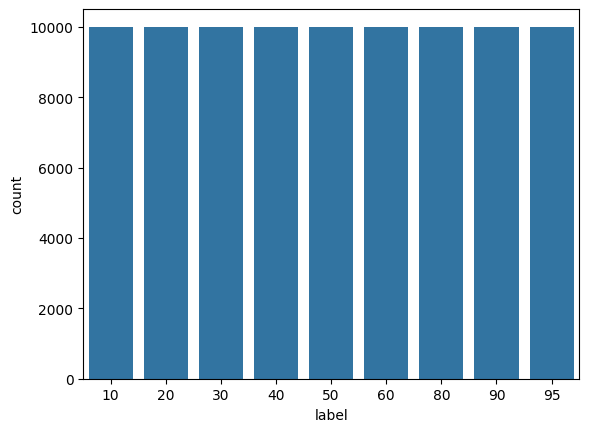

In [10]:
print(df["label"].value_counts()) 
sns.countplot(data=df,x="label")

In [11]:
df.columns
columns = ['Q1_B11', 'Q1_B12', 'Q1_B2', 'Q1_B3', 'Q1_B4', 'Q1_B5', 'Q1_B6',
       'Q1_B7', 'Q1_B8', 'Q1_B8A', 'Q2_B11', 'Q2_B12', 'Q2_B2', 'Q2_B3',
       'Q2_B4', 'Q2_B5', 'Q2_B6', 'Q2_B7', 'Q2_B8', 'Q2_B8A', 'Q3_B11',
       'Q3_B12', 'Q3_B2', 'Q3_B3', 'Q3_B4', 'Q3_B5', 'Q3_B6', 'Q3_B7', 'Q3_B8',
       'Q3_B8A', 'Q4_B11', 'Q4_B12', 'Q4_B2', 'Q4_B3', 'Q4_B4', 'Q4_B5',
       'Q4_B6', 'Q4_B7', 'Q4_B8', 'Q4_B8A'] 

for i in columns: 
    print(f"{i} - {df[i].skew()}") 
    

Q1_B11 - 0.10468930006518937
Q1_B12 - 0.39133264495126335
Q1_B2 - 2.9494402113216216
Q1_B3 - 2.2628662937856707
Q1_B4 - 1.5328315772445458
Q1_B5 - 1.343523203781273
Q1_B6 - 0.6015322099954153
Q1_B7 - 0.2617299671485805
Q1_B8 - 0.1473633247874483
Q1_B8A - -0.10983968214280498
Q2_B11 - 0.2757804205276146
Q2_B12 - 0.5510002684814014
Q2_B2 - 3.2212590358256143
Q2_B3 - 2.5170425665235743
Q2_B4 - 1.8224479097910324
Q2_B5 - 1.5903381219038504
Q2_B6 - 0.7238597737885001
Q2_B7 - 0.3498973955435112
Q2_B8 - 0.26072828241446655
Q2_B8A - -0.016017186629002582
Q3_B11 - 0.6347772606306076
Q3_B12 - 1.457534279231097
Q3_B2 - 3.6507124262824924
Q3_B3 - 2.883662266891001
Q3_B4 - 2.5368737478710313
Q3_B5 - 1.9428852546541235
Q3_B6 - 0.3325761026655351
Q3_B7 - 0.41026534500758355
Q3_B8 - 0.3879403253415524
Q3_B8A - 0.2879577628906419
Q4_B11 - 0.22880204806094614
Q4_B12 - 0.7087742843392059
Q4_B2 - 3.1535380247860902
Q4_B3 - 2.4132393764518345
Q4_B4 - 1.6458411689738546
Q4_B5 - 1.3150344027713612
Q4_B6 - 0.

<Axes: >

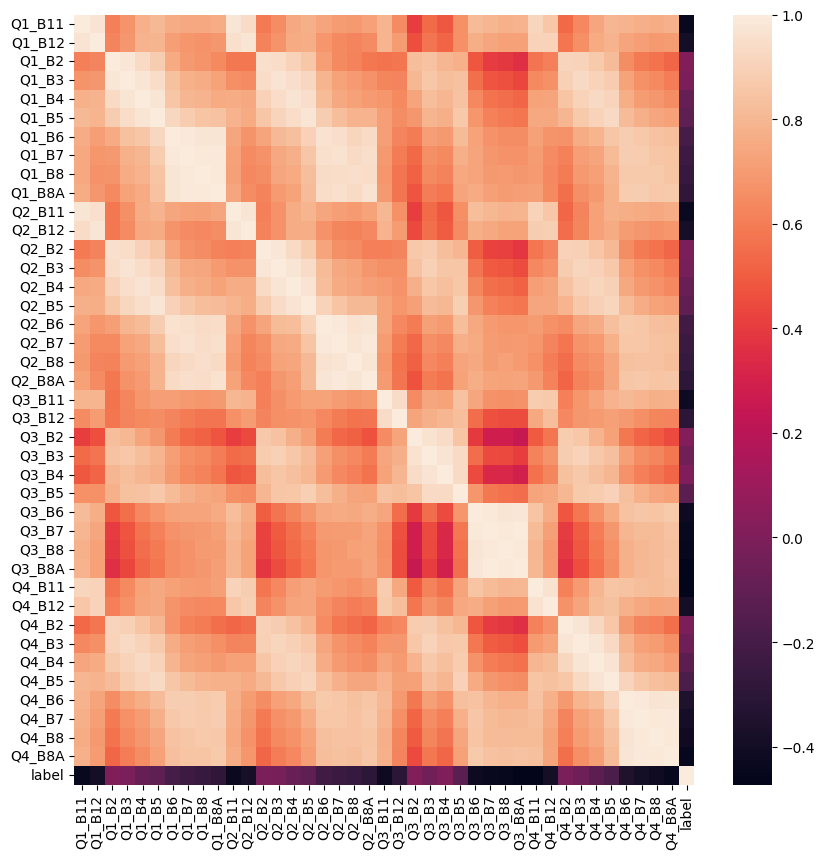

In [12]:
df.corr(numeric_only=True)
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(numeric_only=True))

In [13]:
col_count_per_season = [] 
for i in columns: 
    if "Q1" in i: # change Q1,Q2,Q3,Q4
        col_count_per_season.append(i)
        
print(col_count_per_season) 
print(len(col_count_per_season))

['Q1_B11', 'Q1_B12', 'Q1_B2', 'Q1_B3', 'Q1_B4', 'Q1_B5', 'Q1_B6', 'Q1_B7', 'Q1_B8', 'Q1_B8A']
10


In [14]:
X = df.loc[:,'Q1_B11':'Q4_B8A']
y = df["label"]

In [16]:
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, shuffle=True, stratify=y
)

In [17]:
from sklearn.ensemble import RandomForestClassifier 

rf = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
y_pred = rf.predict(X_test)

In [19]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

          10       0.82      0.82      0.82      1999
          20       0.84      0.85      0.85      1997
          30       0.79      0.80      0.80      1967
          40       0.90      0.92      0.91      1970
          50       0.85      0.82      0.83      2060
          60       0.88      0.86      0.87      2038
          80       0.98      0.99      0.99      1971
          90       0.88      0.83      0.85      2125
          95       0.90      0.96      0.92      1873

    accuracy                           0.87     18000
   macro avg       0.87      0.87      0.87     18000
weighted avg       0.87      0.87      0.87     18000



In [16]:
confusion = pd.DataFrame(confusion_matrix(y_test,y_pred),index= [
    "Tree cover",
    "Shrubland",
    "Grassland",
    "Cropland",
    "Built-up",
    "Bare / sparse vegetation",
    "Permanent water bodies",
    "Herbaceous wetland",
    "Mangroves"
],columns= [
    "Tree cover",
    "Shrubland",
    "Grassland",
    "Cropland",
    "Built-up",
    "Bare / sparse vegetation",
    "Permanent water bodies",
    "Herbaceous wetland",
    "Mangroves"
])
confusion

In [17]:
importance = pd.DataFrame(index=rf.feature_names_in_,data=rf.feature_importances_,columns=["importance"]).sort_values(by="importance",ascending=False)
importance

,importance
Q1_B12,0.063586
Q1_B11,0.058597
Q2_B12,0.048542
Q2_B11,0.041024
Q1_B8A,0.038229
Q3_B4,0.035762
Q3_B12,0.033253
Q1_B4,0.032823
Q3_B2,0.032549
Q4_B12,0.029438


In [18]:
#xgboost

In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_xgb = le.fit_transform(y_train)
y_test_xgb = le.transform(y_test)

le.classes_

array([10, 20, 30, 40, 50, 60, 80, 90, 95])

In [21]:
from xgboost import XGBClassifier 

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=9,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train_xgb)

,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'mlogloss'


In [22]:
y_pred_xgb_encoded = xgb.predict(X_test)
y_pred_xgb = le.inverse_transform(y_pred_xgb_encoded)

In [23]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.8820555555555556

Classification Report:
              precision    recall  f1-score   support

          10       0.83      0.82      0.83      2000
          20       0.85      0.86      0.85      2000
          30       0.82      0.81      0.82      2000
          40       0.93      0.91      0.92      2000
          50       0.85      0.87      0.86      2000
          60       0.87      0.89      0.88      2000
          80       0.99      0.98      0.99      2000
          90       0.84      0.88      0.86      2000
          95       0.96      0.91      0.94      2000

    accuracy                           0.88     18000
   macro avg       0.88      0.88      0.88     18000
weighted avg       0.88      0.88      0.88     18000



In [23]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

pd.DataFrame(
    cm_xgb,
    index=le.classes_,
    columns=le.classes_
)


,10,20,30,40,50,60,80,90,95
10,1647,119,124,2,101,0,0,5,2
20,110,1713,35,0,29,12,0,86,15
30,133,29,1627,125,44,32,0,10,0
40,8,7,160,1815,6,4,0,0,0
50,58,15,34,6,1745,137,0,4,1
60,2,4,5,1,131,1779,5,72,1
80,1,6,1,0,0,14,1960,17,1
90,8,100,5,0,2,61,5,1767,52
95,9,33,0,0,1,0,1,132,1824


In [24]:
#indices

In [25]:
df

,Q1_B11,Q1_B12,Q1_B2,Q1_B3,Q1_B4,Q1_B5,Q1_B6,Q1_B7,Q1_B8,Q1_B8A,...,Q4_B2,Q4_B3,Q4_B4,Q4_B5,Q4_B6,Q4_B7,Q4_B8,Q4_B8A,label,.geo
0,0.21090,0.16760,0.02660,0.0434,0.04740,0.10740,0.1907,0.22590,0.2392,0.26460,...,0.03000,0.0412,0.04840,0.09920,0.1577,0.18820,0.2134,0.2141,10,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
1,0.17810,0.12405,0.02615,0.0462,0.03990,0.09685,0.2119,0.25570,0.2606,0.28410,...,0.02240,0.0482,0.03110,0.09820,0.2357,0.28560,0.3166,0.3112,10,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
2,0.25470,0.17350,0.04565,0.0653,0.08090,0.11660,0.1649,0.18910,0.1857,0.20820,...,0.04985,0.0752,0.08985,0.13235,0.1995,0.22575,0.2462,0.2536,10,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
3,0.11415,0.06155,0.01465,0.0335,0.02510,0.07450,0.1869,0.23405,0.2648,0.25015,...,0.01970,0.0378,0.03420,0.08490,0.1900,0.22880,0.2742,0.2485,10,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
4,0.15410,0.07840,0.01380,0.0360,0.02910,0.09000,0.2214,0.28070,0.2698,0.31980,...,0.01940,0.0402,0.03120,0.09440,0.2303,0.28760,0.2724,0.3182,10,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89995,0.06360,0.03670,0.01360,0.0242,0.02190,0.05070,0.0949,0.10870,0.1248,0.12140,...,0.01650,0.0268,0.02510,0.04900,0.0909,0.10460,0.1306,0.1111,95,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
89996,0.07050,0.03170,0.01720,0.0381,0.02610,0.06020,0.1594,0.19130,0.2160,0.20980,...,0.02430,0.0436,0.03350,0.06600,0.1560,0.18690,0.2274,0.2060,95,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
89997,0.11080,0.06280,0.03350,0.0511,0.06410,0.09640,0.1259,0.14010,0.1484,0.15740,...,0.04570,0.0642,0.07490,0.10540,0.1343,0.14880,0.1730,0.1675,95,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
89998,0.08710,0.04660,0.02980,0.0475,0.05120,0.08930,0.1283,0.14060,0.1290,0.15200,...,0.03100,0.0543,0.05200,0.09700,0.1256,0.13930,0.1290,0.1564,95,"{""geodesic"":false,""type"":""Point"",""coordinates""..."


In [26]:
columns = ['Q1_B11', 'Q1_B12', 'Q1_B2', 'Q1_B3', 'Q1_B4', 'Q1_B5', 'Q1_B6',
       'Q1_B7', 'Q1_B8', 'Q1_B8A', 'Q2_B11', 'Q2_B12', 'Q2_B2', 'Q2_B3',
       'Q2_B4', 'Q2_B5', 'Q2_B6', 'Q2_B7', 'Q2_B8', 'Q2_B8A', 'Q3_B11',
       'Q3_B12', 'Q3_B2', 'Q3_B3', 'Q3_B4', 'Q3_B5', 'Q3_B6', 'Q3_B7', 'Q3_B8',
       'Q3_B8A', 'Q4_B11', 'Q4_B12', 'Q4_B2', 'Q4_B3', 'Q4_B4', 'Q4_B5',
       'Q4_B6', 'Q4_B7', 'Q4_B8', 'Q4_B8A'] 

In [27]:
Q1_NDBI = (df["Q1_B11"]-df["Q1_B8"])/(df["Q1_B11"]+df["Q1_B8"])

In [24]:
def create_indice(df, quarter, indice_name, eps=1e-10):
    if indice_name == "NDBI":
        return (df[f"{quarter}_B11"] - df[f"{quarter}_B8"]) / (df[f"{quarter}_B11"] + df[f"{quarter}_B8"] + eps)
    elif indice_name == "NDVI":
        return (df[f"{quarter}_B8"] - df[f"{quarter}_B4"]) / (df[f"{quarter}_B8"] + df[f"{quarter}_B4"] + eps)
    elif indice_name == "NDRE":
        return (df[f"{quarter}_B8"] - df[f"{quarter}_B5"]) / (df[f"{quarter}_B8"] + df[f"{quarter}_B5"] + eps)
    elif indice_name == "BSI":
        return ((df[f"{quarter}_B11"] + df[f"{quarter}_B4"]) - (df[f"{quarter}_B8"] + df[f"{quarter}_B2"])) / ((df[f"{quarter}_B11"] + df[f"{quarter}_B4"]) + (df[f"{quarter}_B8"] + df[f"{quarter}_B2"]) + eps)
    elif indice_name == "NDWI":
        return (df[f"{quarter}_B3"] - df[f"{quarter}_B8"]) / (df[f"{quarter}_B3"] + df[f"{quarter}_B8"] + eps)
    elif indice_name == "MNDWI":
        return (df[f"{quarter}_B3"] - df[f"{quarter}_B11"]) / (df[f"{quarter}_B3"] + df[f"{quarter}_B11"] + eps)
    elif indice_name == "EVI":
        return 2.5 * (df[f"{quarter}_B8"] - df[f"{quarter}_B4"]) / (df[f"{quarter}_B8"] + 6 * df[f"{quarter}_B4"] - 7.5 * df[f"{quarter}_B2"] + 1 + eps)
    else:
        raise ValueError(f"Unknown indice_name: {indice_name}")

In [25]:
indices_df = pd.DataFrame(index=df.index)

quarter = ["Q1","Q2","Q3","Q4"]
indices = ["NDVI", "NDRE", "NDBI", "BSI", "NDWI", "MNDWI", "EVI"]

for i in quarter: 
    for j in indices: 
        indices_df[f"{i}_{j}"] = create_indice(df,i,j)

In [26]:
new_indice_df = pd.concat(objs=[df,indices_df],axis=1)
new_indice_df

,Q1_B11,Q1_B12,Q1_B2,Q1_B3,Q1_B4,Q1_B5,Q1_B6,Q1_B7,Q1_B8,Q1_B8A,...,Q3_NDWI,Q3_MNDWI,Q3_EVI,Q4_NDVI,Q4_NDRE,Q4_NDBI,Q4_BSI,Q4_NDWI,Q4_MNDWI,Q4_EVI
0,0.21090,0.16760,0.02660,0.0434,0.04740,0.10740,0.1907,0.22590,0.2392,0.26460,...,-0.696789,-0.644172,0.350803,0.630252,0.365323,0.025126,0.056955,-0.676355,-0.689759,0.322568
1,0.17810,0.12405,0.02615,0.0462,0.03990,0.09685,0.2119,0.25570,0.2606,0.28410,...,-0.603896,-0.604110,0.246443,0.821110,0.526519,-0.269956,-0.228038,-0.735746,-0.581234,0.534564
2,0.25470,0.17350,0.04565,0.0653,0.08090,0.11660,0.1649,0.18910,0.1857,0.20820,...,-0.648619,-0.560773,0.352953,0.465258,0.300753,0.005253,0.067118,-0.532047,-0.535802,0.276936
3,0.11415,0.06155,0.01465,0.0335,0.02510,0.07450,0.1869,0.23405,0.2648,0.25015,...,-0.795115,-0.517572,0.469820,0.778210,0.527151,-0.356754,-0.283126,-0.757692,-0.549464,0.450569
4,0.15410,0.07840,0.01380,0.0360,0.02910,0.09000,0.2214,0.28070,0.2698,0.31980,...,-0.778489,-0.647583,0.385582,0.794466,0.485278,-0.197363,-0.154272,-0.742802,-0.639138,0.458869
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89995,0.06360,0.03670,0.01360,0.0242,0.02190,0.05070,0.0949,0.10870,0.1248,0.12140,...,-0.689478,-0.497578,0.183672,0.677585,0.454343,-0.352667,-0.253515,-0.659466,-0.399776,0.227872
89996,0.07050,0.03170,0.01720,0.0381,0.02610,0.06020,0.1594,0.19130,0.2160,0.20980,...,-0.788352,-0.458465,0.342935,0.743197,0.550102,-0.480951,-0.379556,-0.678229,-0.292782,0.388998
89997,0.11080,0.06280,0.03350,0.0511,0.06410,0.09640,0.1259,0.14010,0.1484,0.15740,...,-0.552586,-0.354027,0.198454,0.395724,0.242816,-0.175671,-0.054230,-0.458685,-0.307817,0.191654
89998,0.08710,0.04660,0.02980,0.0475,0.05120,0.08930,0.1283,0.14060,0.1290,0.15200,...,-0.496301,-0.245233,0.179443,0.425414,0.141593,-0.173794,-0.056803,-0.407529,-0.251551,0.159288


In [27]:
X = new_indice_df[['Q1_B11', 'Q1_B12', 'Q1_B2', 'Q1_B3', 'Q1_B4', 'Q1_B5', 'Q1_B6',
       'Q1_B7', 'Q1_B8', 'Q1_B8A', 'Q2_B11', 'Q2_B12', 'Q2_B2', 'Q2_B3',
       'Q2_B4', 'Q2_B5', 'Q2_B6', 'Q2_B7', 'Q2_B8', 'Q2_B8A', 'Q3_B11',
       'Q3_B12', 'Q3_B2', 'Q3_B3', 'Q3_B4', 'Q3_B5', 'Q3_B6', 'Q3_B7', 'Q3_B8',
       'Q3_B8A', 'Q4_B11', 'Q4_B12', 'Q4_B2', 'Q4_B3', 'Q4_B4', 'Q4_B5',
       'Q4_B6', 'Q4_B7', 'Q4_B8', 'Q4_B8A', 'Q1_NDVI',
       'Q1_NDRE', 'Q1_NDBI', 'Q1_BSI', 'Q1_NDWI', 'Q1_MNDWI', 'Q1_EVI',
       'Q2_NDVI', 'Q2_NDRE', 'Q2_NDBI', 'Q2_BSI', 'Q2_NDWI', 'Q2_MNDWI',
       'Q2_EVI', 'Q3_NDVI', 'Q3_NDRE', 'Q3_NDBI', 'Q3_BSI', 'Q3_NDWI',
       'Q3_MNDWI', 'Q3_EVI', 'Q4_NDVI', 'Q4_NDRE', 'Q4_NDBI', 'Q4_BSI',
       'Q4_NDWI', 'Q4_MNDWI', 'Q4_EVI']]

y = new_indice_df["label"]

In [28]:
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, shuffle=True, stratify=y
)

In [29]:
from sklearn.ensemble import RandomForestClassifier 

rf = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
y_pred = rf.predict(X_test)

In [31]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

          10       0.82      0.82      0.82      1997
          20       0.84      0.85      0.84      1965
          30       0.79      0.79      0.79      1992
          40       0.90      0.92      0.91      1947
          50       0.85      0.82      0.84      2056
          60       0.89      0.87      0.88      2057
          80       0.98      1.00      0.99      1969
          90       0.88      0.84      0.86      2117
          95       0.90      0.95      0.93      1900

    accuracy                           0.87     18000
   macro avg       0.87      0.87      0.87     18000
weighted avg       0.87      0.87      0.87     18000



In [36]:
confusion = pd.DataFrame(confusion_matrix(y_test,y_pred),index= [
    "Tree cover",
    "Shrubland",
    "Grassland",
    "Cropland",
    "Built-up",
    "Bare / sparse vegetation",
    "Permanent water bodies",
    "Herbaceous wetland",
    "Mangroves"
],columns= [
    "Tree cover",
    "Shrubland",
    "Grassland",
    "Cropland",
    "Built-up",
    "Bare / sparse vegetation",
    "Permanent water bodies",
    "Herbaceous wetland",
    "Mangroves"
])

confusion

,Tree cover,Shrubland,Grassland,Cropland,Built-up,Bare / sparse vegetation,Permanent water bodies,Herbaceous wetland,Mangroves
Tree cover,1637,113,140,0,98,0,0,5,7
Shrubland,131,1675,29,1,44,5,0,94,21
Grassland,140,33,1582,143,60,31,0,11,0
Cropland,5,7,187,1793,5,3,0,0,0
Built-up,56,16,44,8,1695,169,0,8,4
Bare / sparse vegetation,0,0,5,1,141,1780,5,66,2
Permanent water bodies,1,4,0,0,0,14,1960,19,2
Herbaceous wetland,11,86,5,1,10,55,3,1769,60
Mangroves,16,31,0,0,3,0,1,145,1804


In [37]:
importance = pd.DataFrame(index=rf.feature_names_in_,data=rf.feature_importances_,columns=["importance"]).sort_values(by="importance",ascending=False)
importance

,importance
Q1_B11,0.061465
Q1_B12,0.039756
Q2_B12,0.036137
Q2_B11,0.033659
Q2_NDVI,0.029650
...,...
Q4_B3,0.005282
Q3_NDBI,0.005262
Q4_B6,0.005237
Q4_NDBI,0.005033
